# Notebook 4: Visualization and Analysis
## Real-Time Air Quality Monitoring Agent

**Purpose:** This notebook produces comprehensive visualisations to communicate
pollution patterns, model results, and spatial/temporal trends to both technical
and non-technical audiences.

**Prerequisites:** Run Notebooks 01, 02, and 03 first.

**Key outputs:** Charts saved to `plots/` folder; findings summarised for reporting.

In [1]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 1 — Imports and configuration
# plotly provides interactive charts; folium creates maps.
# matplotlib and seaborn handle static publication-quality plots.
# ─────────────────────────────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
import os

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams.update({'figure.figsize': (13, 5), 'axes.titlesize': 13})

os.makedirs('plots', exist_ok=True)  # All charts saved here
print('✅ Libraries loaded')

✅ Libraries loaded


In [2]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 2 — Load predictions dataset produced by Notebook 3
# ─────────────────────────────────────────────────────────────────────────────
df = pd.read_csv('data/predictions.csv', parse_dates=['Date'])
print(f'✅ Loaded {df.shape[0]} rows × {df.shape[1]} columns')

# AQI colour palette — matches CPCB official colour coding
AQI_COLORS = {
    'Good':         '#00e400',
    'Satisfactory': '#92d050',
    'Moderate':     '#ffff00',
    'Poor':         '#ff7e00',
    'Very Poor':    '#ff0000',
    'Severe':       '#7e0023',
}
CAT_ORDER = ['Good','Satisfactory','Moderate','Poor','Very Poor','Severe']

✅ Loaded 5000 rows × 46 columns


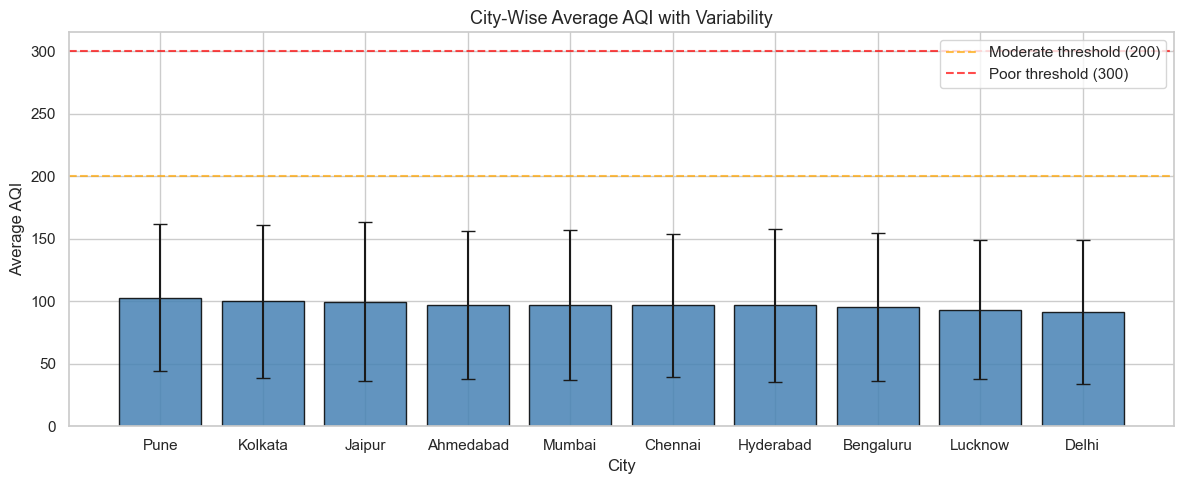

✅ Chart 1 saved


In [3]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 3 — City-wise Average AQI Bar Chart
#
# This chart answers: Which cities are most/least polluted on average?
# Error bars show ±1 standard deviation, revealing variability.
# ─────────────────────────────────────────────────────────────────────────────
city_aqi = df.groupby('City')['AQI_Official'].agg(['mean','std']).reset_index()
city_aqi = city_aqi.sort_values('mean', ascending=False)

fig, ax = plt.subplots(figsize=(12, 5))
bars = ax.bar(city_aqi['City'], city_aqi['mean'],
              yerr=city_aqi['std'], capsize=5,
              color='steelblue', edgecolor='black', alpha=0.85)
ax.axhline(200, color='orange', linestyle='--', alpha=0.7, label='Moderate threshold (200)')
ax.axhline(300, color='red',    linestyle='--', alpha=0.7, label='Poor threshold (300)')
ax.set_xlabel('City'); ax.set_ylabel('Average AQI')
ax.set_title('City-Wise Average AQI with Variability')
ax.legend(); plt.tight_layout()
plt.savefig('plots/city_aqi_bar.png', dpi=150)
plt.show()
print('✅ Chart 1 saved')

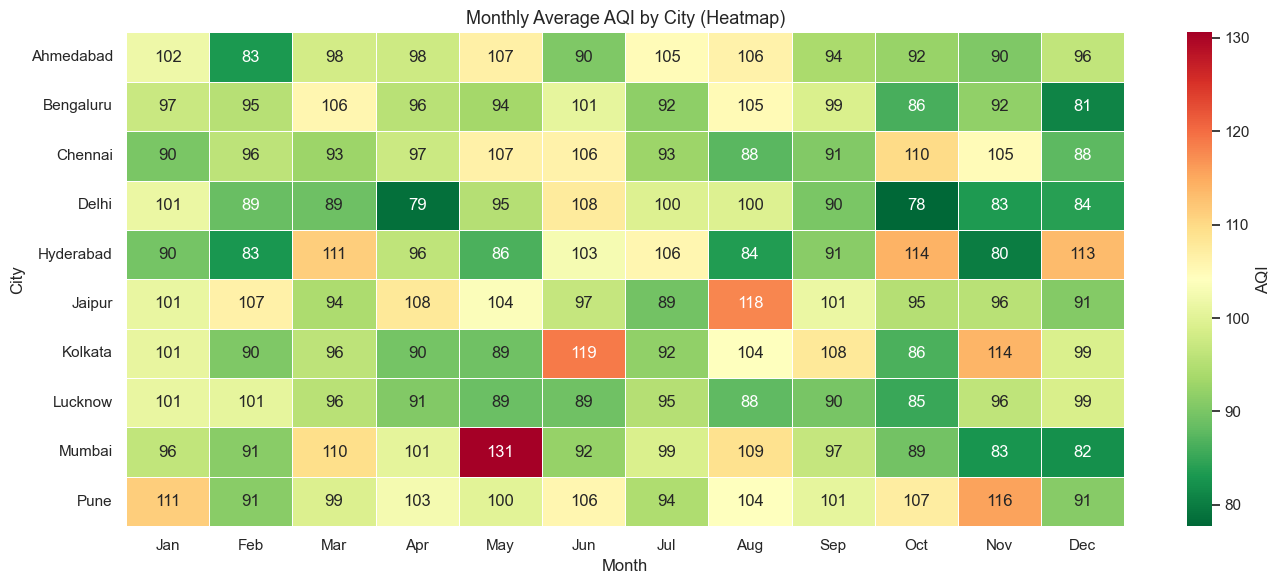

✅ Chart 2 saved


In [4]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 4 — Monthly AQI Trend (Heatmap by City × Month)
#
# A pivot heatmap reveals seasonal patterns across cities simultaneously.
# Darker shades indicate worse air quality, helping policymakers target
# high-risk months for intervention.
# ─────────────────────────────────────────────────────────────────────────────
pivot = df.pivot_table(values='AQI_Official', index='City',
                       columns='Month', aggfunc='mean').round(1)
pivot.columns = ['Jan','Feb','Mar','Apr','May','Jun',
                 'Jul','Aug','Sep','Oct','Nov','Dec']

plt.figure(figsize=(14, 6))
sns.heatmap(pivot, cmap='RdYlGn_r', annot=True, fmt='.0f',
            linewidths=0.5, cbar_kws={'label': 'AQI'})
plt.title('Monthly Average AQI by City (Heatmap)')
plt.xlabel('Month'); plt.ylabel('City')
plt.tight_layout()
plt.savefig('plots/monthly_aqi_heatmap.png', dpi=150)
plt.show()
print('✅ Chart 2 saved')

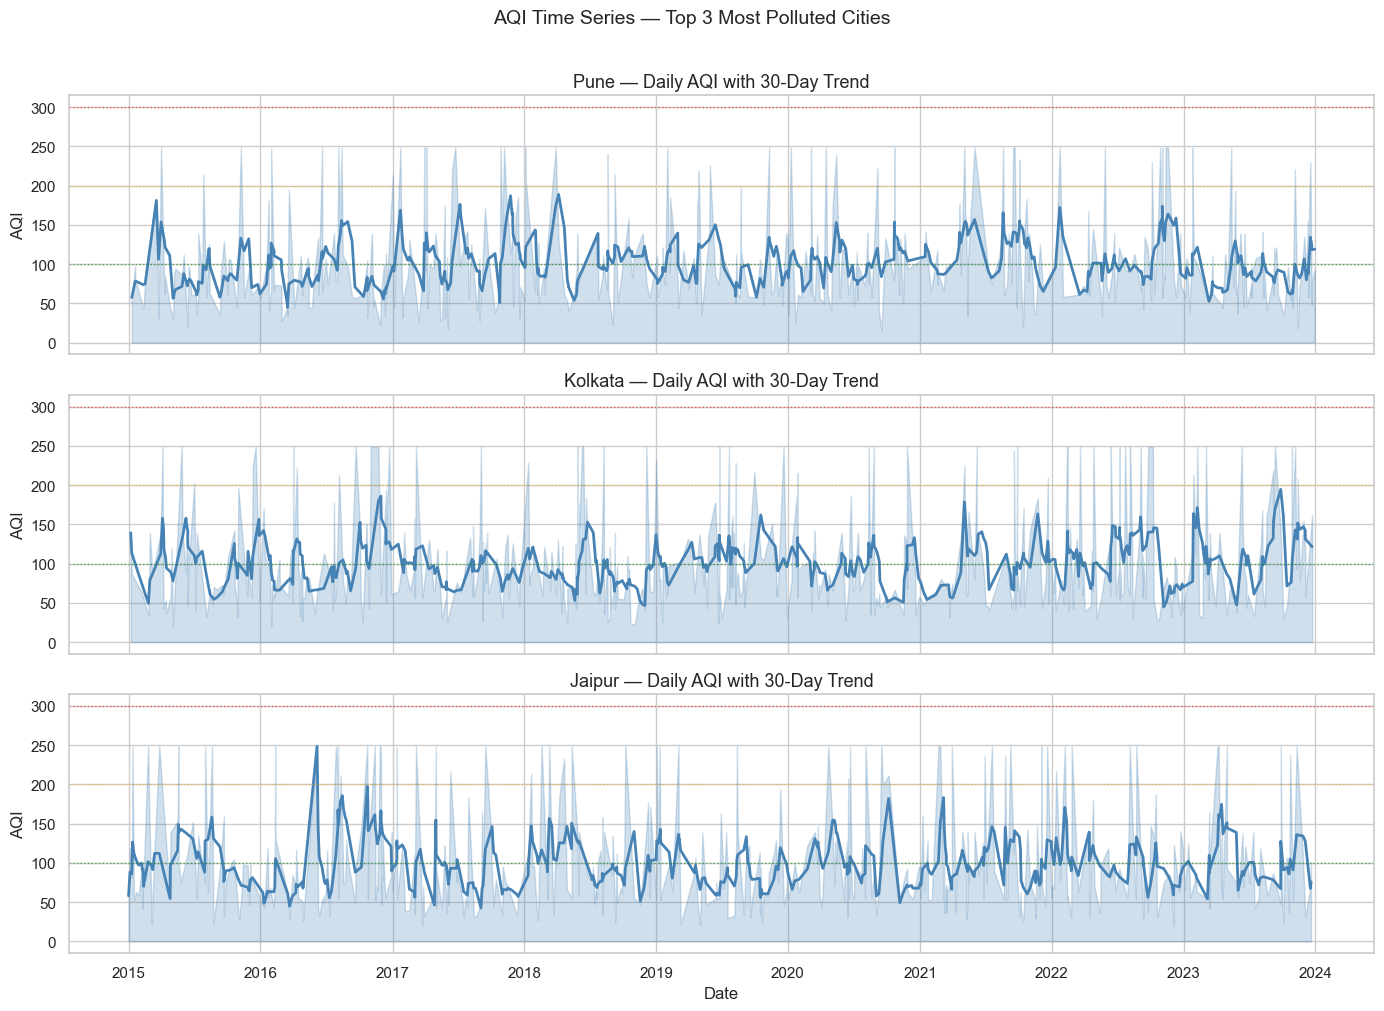

✅ Chart 3 saved


In [5]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 5 — AQI Time Series for Top 3 Most Polluted Cities
#
# A rolling 30-day average smooths daily noise and reveals long-term trends.
# Shaded bands show raw daily variability around the smoothed trend.
# ─────────────────────────────────────────────────────────────────────────────
top3_cities = city_aqi.head(3)['City'].tolist()
fig, axes   = plt.subplots(3, 1, figsize=(14, 10), sharex=True)

for ax, city in zip(axes, top3_cities):
    city_df = df[df['City'] == city].sort_values('Date')
    # Plot raw daily AQI as a semi-transparent fill
    ax.fill_between(city_df['Date'], city_df['AQI_Official'],
                    alpha=0.25, color='steelblue')
    # Overlay 30-day rolling mean as a bold line
    rolling = city_df.set_index('Date')['AQI_Official'].rolling('30D').mean()
    ax.plot(rolling.index, rolling.values, color='steelblue', linewidth=2)
    # Add CPCB threshold lines
    for threshold, color, label in [(100,'green','Good/Satisfactory'),
                                     (200,'orange','Moderate'),
                                     (300,'red','Poor')]:
        ax.axhline(threshold, color=color, linestyle=':', alpha=0.6, linewidth=1)
    ax.set_ylabel('AQI'); ax.set_title(f'{city} — Daily AQI with 30-Day Trend')

plt.xlabel('Date')
plt.suptitle('AQI Time Series — Top 3 Most Polluted Cities', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig('plots/aqi_timeseries.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Chart 3 saved')

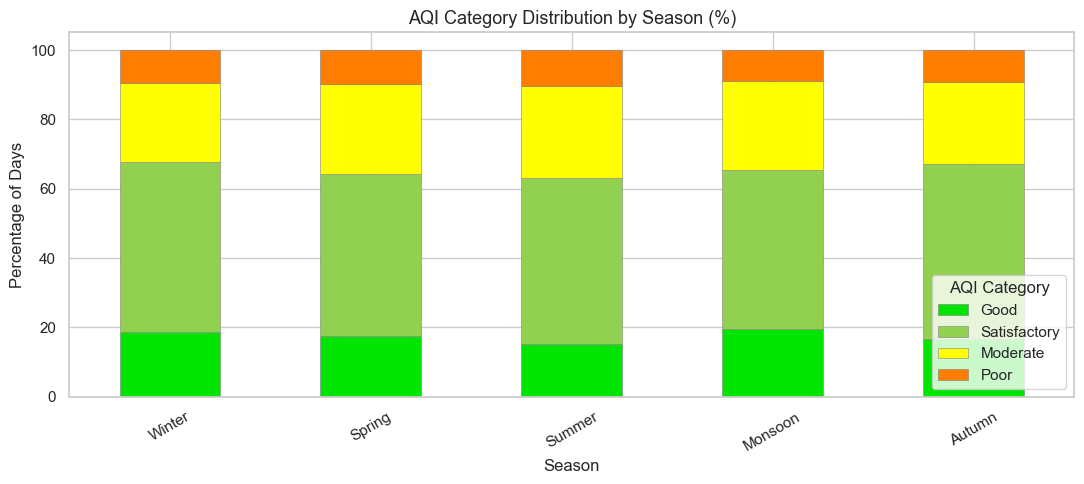

✅ Chart 4 saved


In [6]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 6 — AQI Category Stacked Bar by Season
#
# Shows what fraction of days fall in each AQI category per season.
# Seasonal comparison directly informs public health messaging:
# e.g., "Winter has the highest proportion of 'Very Poor' days."
# ─────────────────────────────────────────────────────────────────────────────
season_cat = df.groupby(['Season', 'AQI_Category']).size().reset_index(name='Count')
season_pct = season_cat.copy()
totals = season_pct.groupby('Season')['Count'].transform('sum')
season_pct['Pct'] = (season_pct['Count'] / totals * 100).round(1)

pivot_pct = season_pct.pivot(index='Season', columns='AQI_Category', values='Pct').fillna(0)
pivot_pct = pivot_pct.reindex(columns=[c for c in CAT_ORDER if c in pivot_pct.columns])

season_order = ['Winter','Spring','Summer','Monsoon','Autumn']
pivot_pct = pivot_pct.reindex([s for s in season_order if s in pivot_pct.index])

ax = pivot_pct.plot(kind='bar', stacked=True,
                    color=[AQI_COLORS[c] for c in pivot_pct.columns],
                    figsize=(11, 5), edgecolor='grey', linewidth=0.4)
ax.set_title('AQI Category Distribution by Season (%)')
ax.set_ylabel('Percentage of Days')
ax.set_xlabel('Season')
ax.legend(loc='lower right', title='AQI Category')
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig('plots/season_category_bar.png', dpi=150)
plt.show()
print('✅ Chart 4 saved')

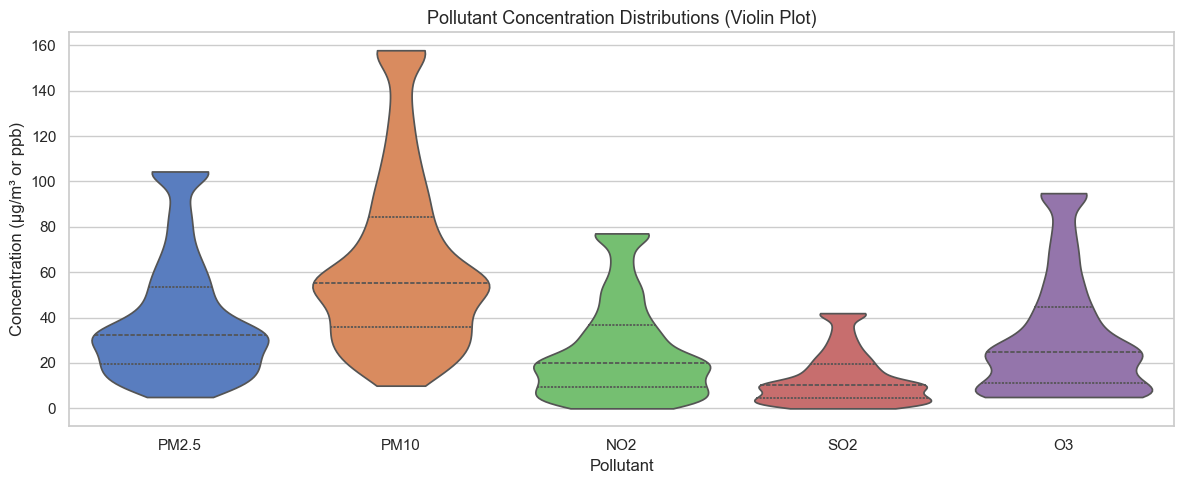

✅ Chart 5 saved


In [7]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 7 — Pollutant Concentration Violin Plot
#
# Violin plots combine the information of a box plot with a kernel density
# estimate, showing the full distribution shape.  This reveals whether
# pollutants are uniformly distributed or have heavy tails.
# ─────────────────────────────────────────────────────────────────────────────
pollutants = ['PM2.5', 'PM10', 'NO2', 'SO2', 'O3']
df_melt = df[pollutants].melt(var_name='Pollutant', value_name='Concentration')

plt.figure(figsize=(12, 5))
sns.violinplot(data=df_melt, x='Pollutant', y='Concentration',
               palette='muted', inner='quartile', cut=0)
plt.title('Pollutant Concentration Distributions (Violin Plot)')
plt.ylabel('Concentration (µg/m³ or ppb)')
plt.tight_layout()
plt.savefig('plots/pollutant_violin.png', dpi=150)
plt.show()
print('✅ Chart 5 saved')

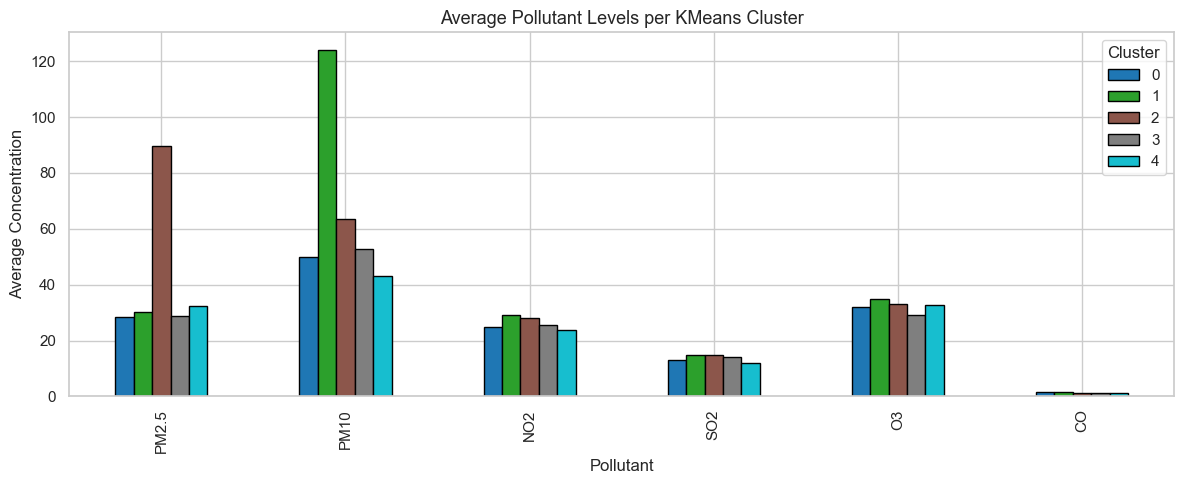

Cluster profiles (mean pollutant levels):
         PM2.5    PM10    NO2    SO2     O3    CO
Cluster                                          
0        28.59   49.81  24.83  13.07  31.88  1.42
1        30.21  124.17  29.12  14.79  34.86  1.45
2        89.56   63.41  27.93  14.96  32.97  1.25
3        28.92   52.84  25.59  13.96  29.25  1.38
4        32.46   43.06  23.78  11.91  32.82  1.38
✅ Chart 6 saved


In [8]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 8 — Cluster Profile Plot
#
# Shows the average pollutant levels within each KMeans cluster.
# This characterises clusters semantically:
#  e.g., Cluster 2 might have high PM2.5 → 'Combustion-dominated cluster'
# Radar/spider plots or grouped bar charts work well for this purpose.
# ─────────────────────────────────────────────────────────────────────────────
key_cols = ['PM2.5', 'PM10', 'NO2', 'SO2', 'O3', 'CO']
cluster_profile = df.groupby('Cluster')[key_cols].mean().round(2)

ax = cluster_profile.T.plot(kind='bar', figsize=(12, 5),
                             colormap='tab10', edgecolor='black')
ax.set_title('Average Pollutant Levels per KMeans Cluster')
ax.set_ylabel('Average Concentration')
ax.set_xlabel('Pollutant')
ax.legend(title='Cluster', bbox_to_anchor=(1, 1))
plt.tight_layout()
plt.savefig('plots/cluster_profile.png', dpi=150, bbox_inches='tight')
plt.show()

print('Cluster profiles (mean pollutant levels):')
print(cluster_profile)
print('✅ Chart 6 saved')

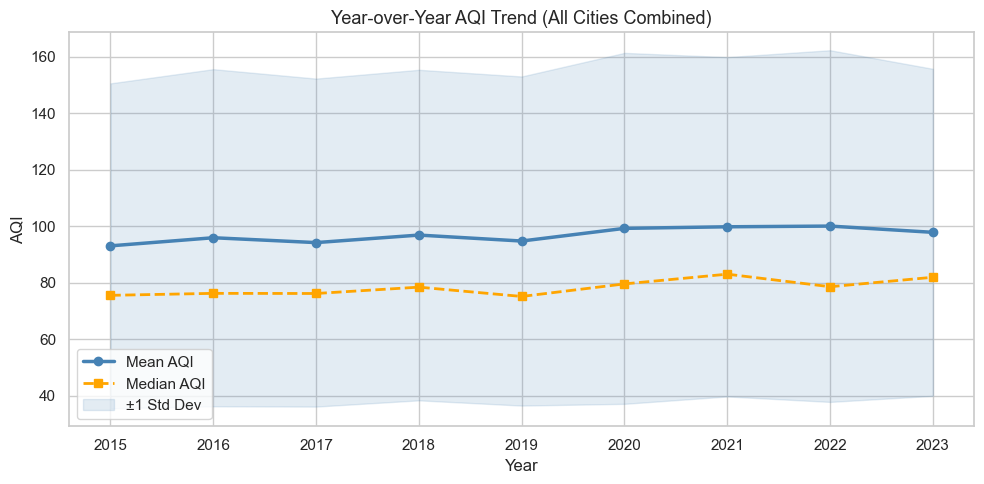

✅ Chart 7 saved


In [9]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 9 — Year-over-Year AQI Trend (Line Chart)
#
# Tracks whether air quality is improving or degrading over the years.
# This is crucial for policy evaluation: did government interventions work?
# ─────────────────────────────────────────────────────────────────────────────
yearly = df.groupby('Year')['AQI_Official'].agg(['mean','median','std']).reset_index()

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(yearly['Year'], yearly['mean'], 'o-', color='steelblue',
        linewidth=2.5, label='Mean AQI')
ax.plot(yearly['Year'], yearly['median'], 's--', color='orange',
        linewidth=2, label='Median AQI')
ax.fill_between(yearly['Year'],
                yearly['mean'] - yearly['std'],
                yearly['mean'] + yearly['std'],
                alpha=0.15, color='steelblue', label='±1 Std Dev')
ax.set_xlabel('Year'); ax.set_ylabel('AQI')
ax.set_title('Year-over-Year AQI Trend (All Cities Combined)')
ax.legend(); plt.tight_layout()
plt.savefig('plots/yearly_trend.png', dpi=150)
plt.show()
print('✅ Chart 7 saved')

In [10]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 10 — Summary statistics table
#
# A final printout of key findings for inclusion in the report (Notebook 5).
# ─────────────────────────────────────────────────────────────────────────────
print('=' * 55)
print('KEY FINDINGS SUMMARY')
print('=' * 55)

most_polluted   = city_aqi.iloc[0]
least_polluted  = city_aqi.iloc[-1]
worst_month_idx = df.groupby('Month')['AQI_Official'].mean().idxmax()
best_month_idx  = df.groupby('Month')['AQI_Official'].mean().idxmin()
month_names     = {1:'Jan',2:'Feb',3:'Mar',4:'Apr',5:'May',6:'Jun',
                   7:'Jul',8:'Aug',9:'Sep',10:'Oct',11:'Nov',12:'Dec'}

print(f'  Most polluted city  : {most_polluted["City"]} (avg AQI {most_polluted["mean"]:.1f})')
print(f'  Least polluted city : {least_polluted["City"]} (avg AQI {least_polluted["mean"]:.1f})')
print(f'  Worst month         : {month_names[worst_month_idx]}')
print(f'  Best month          : {month_names[best_month_idx]}')
print(f'  Overall avg AQI     : {df["AQI_Official"].mean():.1f}')
print(f'  Severe days (>400)  : {(df["AQI_Official"]>400).sum()} ({(df["AQI_Official"]>400).mean()*100:.1f}%)')
print('=' * 55)
print('✅ All visualisations saved to plots/')

KEY FINDINGS SUMMARY
  Most polluted city  : Pune (avg AQI 102.7)
  Least polluted city : Delhi (avg AQI 91.4)
  Worst month         : Jun
  Best month          : Dec
  Overall avg AQI     : 96.9
  Severe days (>400)  : 0 (0.0%)
✅ All visualisations saved to plots/
